# Transfer Learning and Distillation Experiments

This notebook implements VGG16 feature extraction and knowledge distillation using the tuned baseline architecture as the student.


In [30]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import os
import sys
import json
import random
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
from keras import layers

#from helpers import data_utils, model_utils, training_utils, visualization
import sys
import importlib

# Point to the folder containing the 'helpers' folder
sys.path.append('/content/drive/MyDrive/Colab Notebooks')


from helpers import data_utils, model_utils, training_utils, visualization
importlib.reload(data_utils)
importlib.reload(model_utils)
importlib.reload(training_utils)
importlib.reload(visualization)



keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)


TensorFlow: 2.19.0
Keras: 3.13.2


In [15]:
USE_COLAB = True
USE_KAGGLE = False  # Set True when running on Kaggle

In [16]:
# Configuration
if USE_KAGGLE:
    DATASET_ROOT = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/"
    SAVE_DIR = pathlib.Path("/kaggle/working/saved_models")
elif USE_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATASET_ROOT = "/content/drive/MyDrive/x-ray-dataset/"
    SAVE_DIR = pathlib.Path("/content/drive/MyDrive/saved_models")
else:
    DATASET_ROOT = "dataset"
    SAVE_DIR = pathlib.Path("saved_models")

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR   = os.path.join(DATASET_ROOT, "val")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT  = 0.1
AUTOTUNE   = tf.data.AUTOTUNE

for split_path in [TRAIN_DIR, TEST_DIR]:
    if not os.path.isdir(split_path):
        raise FileNotFoundError(f"Missing directory: {split_path}")

SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Model checkpoint paths
TEACHER_CHECKPOINT_PATH  = SAVE_DIR / "vgg16_frozen_best_checkpoint.keras"
FINETUNE_CHECKPOINT_PATH = SAVE_DIR / "vgg16_finetuned_best_checkpoint.keras"

runtime_name = "Kaggle" if USE_KAGGLE else ("Google Colab" if USE_COLAB else "Local")
print(f"Environment:  {runtime_name}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Save dir:     {SAVE_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment:  Google Colab
Dataset root: /content/drive/MyDrive/x-ray-dataset/
Save dir:     /content/drive/MyDrive/saved_models


In [17]:
# Bind a notebook-local saver without redefining utility functions here.
save_model_with_meta = training_utils.make_model_saver(SAVE_DIR)


In [18]:
# Gather train(+optional original val) and test paths/labels
all_train_paths, all_train_labels, test_paths, test_labels = data_utils.gather_split_paths_labels(
    TRAIN_DIR,
    TEST_DIR,
    val_dir=VAL_DIR,
)

if len(np.unique(all_train_labels)) < 2:
    raise ValueError("Both NORMAL and PNEUMONIA classes must exist in the training pool.")

print(f"Training pool size (train + optional original val): {len(all_train_paths)} images")
print(f"  NORMAL={(all_train_labels==0).sum()}, PNEUMONIA={(all_train_labels==1).sum()}")
print(f"Test set size: {len(test_paths)} images")


Training pool size (train + optional original val): 5232 images
  NORMAL=1349, PNEUMONIA=3883
Test set size: 624 images


In [19]:
data_augmentation = data_utils.build_data_augmentation(
    rotation=30,
    width_shift=0.1,
    height_shift=0.1,
    shear=0.2,
    zoom=0.2,
)

# Build train/val/test datasets with raw [0, 255] images.
# VGG16 preprocessing is applied internally by the model after augmentation —
# do NOT pass a preprocess_fn here to avoid double-preprocessing.
train_ds, val_ds, test_ds, ds_meta = data_utils.build_train_val_test_datasets(
    all_train_paths,
    all_train_labels,
    test_paths,
    test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT,
    seed=42,
    autotune=AUTOTUNE,
)

# Paper-aligned class weights: penalise missed pneumonia cases 4x
# (clinical priority to minimise false negatives), matching the paper's
# explicit value of weight=4 for the PNEUMONIA class.
class_weights = {0: 1.0, 1: 4.0}

print(f"Train split -> NORMAL={ds_meta['normal_count']}, PNEUMONIA={ds_meta['pneumonia_count']}")
print(f"Validation size: {len(ds_meta['val_labels'])}")
print("Class weights:", class_weights)
print("Datasets are ready.")


Train split -> NORMAL=1214, PNEUMONIA=3494
Validation size: 524
Class weights: {0: 1.0, 1: 4.0}
Datasets are ready.


## VGG16 Training

In [20]:
# ── Phase 1: Feature extraction with frozen VGG16 base ──────────────────────
# Raw [0,255] datasets are used; the model applies VGG16 preprocessing
# internally after augmentation (no double-preprocessing).

teacher_model = model_utils.build_vgg16_model(
    img_size=IMG_SIZE,
    augmentation_layer=data_augmentation,
    dense_units=256,
    dense_units_2=128,
    dropout=0.5,
    dropout_2=0.3,
    learning_rate=1e-4,
    freeze_base=True,
    name="vgg16_frozen",
)
teacher_model.summary(show_trainable=True)

teacher_callbacks = training_utils.get_training_callbacks(
    checkpoint_path=TEACHER_CHECKPOINT_PATH,
    patience=7,
    monitor="val_auc",
)

teacher_history = teacher_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=teacher_callbacks,
    class_weight=class_weights,
    verbose=1,
)
print(f"Phase 1 complete. Best checkpoint saved to: {TEACHER_CHECKPOINT_PATH}")


Model: "vgg16_frozen"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_4     │ (None, 224,     │         0 │ -              │   -   │
│ (InputLayer)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ data_augmentation │ (None, 224,     │         0 │ input_layer_4… │   -   │
│ (Sequential)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item_3        │ (None, 224,     │         0 │ data_augmenta… │   -   │
│ (GetItem)         │ 224)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item_4        │ (None, 224,     │         0 │ data_augmenta… │   -   │
│ (GetItem)         │ 224)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item_5        │ (None, 224,     │         0 │ data_augmenta… │   -   │
│ (GetItem)         │ 224)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stack_1 (Stack)   │ (None, 224,     │         0 │ get_item_3[0]… │   -   │
│                   │ 224, 3)         │           │ get_item_4[0]… │       │
│                   │                 │           │ get_item_5[0]… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ add_1 (Add)       │ (None, 224,     │         0 │ stack_1[0][0]  │   -   │
│                   │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ vgg16             │ (None, 7, 7,    │ 14,714,6… │ add_1[0][0]    │   N   │
│ (Functional)      │ 512)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 512)     │         0 │ vgg16[0][0]    │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_3 (Dense)   │ (None, 256)     │   131,328 │ global_averag… │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ batch_normalizat… │ (None, 256)     │     1,024 │ dense_3[0][0]  │   Y   │
│ (BatchNormalizat… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_2         │ (None, 256)     │         0 │ batch_normali… │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_4 (Dense)   │ (None, 128)     │    32,896 │ dropout_2[0][… │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ batch_normalizat… │ (None, 128)     │       512 │ dense_4[0][0]  │   Y   │
│ (BatchNormalizat… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_3         │ (None, 128)     │         0 │ batch_normali… │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_5 (Dense)   │ (None, 1)       │       129 │ dropout_3[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 14,880,577 (56.76 MB)

 Trainable params: 165,121 (645.00 KB)

 Non-trainable params: 14,715,456 (56.14 MB)

Epoch 1/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5902 - auc: 0.6473 - loss: 2.6661 - precision: 0.8242 - recall: 0.5762
Epoch 1: val_auc improved from None to 0.90353, saving model to /content/drive/MyDrive/saved_models/vgg16_frozen_best_checkpoint.keras

Epoch 1: finished saving model to /content/drive/MyDrive/saved_models/vgg16_frozen_best_checkpoint.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.6546 - auc: 0.7388 - loss: 2.3471 - precision: 0.8643 - recall: 0.6342 - val_accuracy: 0.3664 - val_auc: 0.9035 - val_loss: 2.0938 - val_precision: 0.9831 - val_recall: 0.1491 - learning_rate: 1.0000e-04
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7609 - auc: 0.8691 - loss: 1.8462 - precision: 0.9298 - recall: 0.7371
Epoch 2: val_auc improved from 0.90353 to 0.93069, saving model to /content/drive/MyDrive/saved_models/vgg16_frozen_best_checkpoint.keras

Epoch 2: finished saving model to /content/drive/MyDrive/saved_models/vgg16_frozen_bes

In [22]:
def load_model_compat_local(model_path, compile=True):
    import keras

    try:
        return keras.models.load_model(model_path, compile=compile)

    except Exception as first_error:
        random_shear_cls = keras.layers.RandomShear

        # Correct way to store original
        original_from_config = getattr(random_shear_cls, "from_config")

        def _patched_from_config(cls, config):
            config = dict(config)

            # Fix x_factor / y_factor ranges
            for key in ("x_factor", "y_factor"):
                value = config.get(key)
                if isinstance(value, (list, tuple)) and len(value) == 2:
                    low, high = float(value[0]), float(value[1])
                    # Convert [-a, a] → a
                    config[key] = max(abs(low), abs(high))

            return original_from_config(config)

        # Apply patch
        random_shear_cls.from_config = classmethod(_patched_from_config)

        try:
            return keras.models.load_model(model_path, compile=compile)

        except Exception:
            raise first_error

        finally:
            # Restore original
            random_shear_cls.from_config = original_from_config

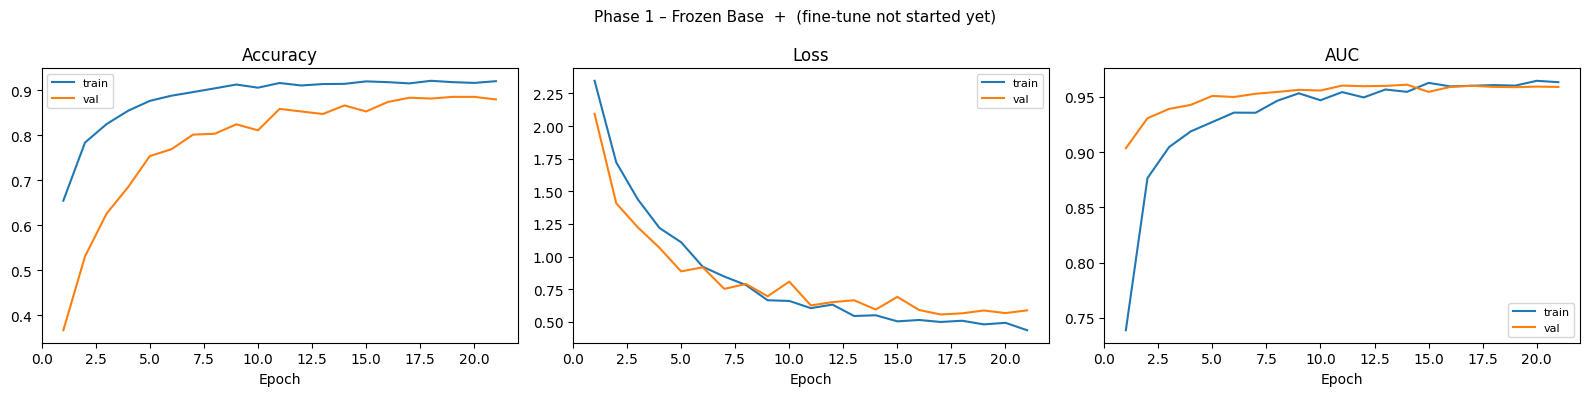

Unfrozen: {'block5_conv1', 'block5_pool', 'block5_conv2', 'block5_conv3'}
Trainable params after unfreeze: 7,244,545
Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9262 - auc: 0.9633 - loss: 0.5105 - precision: 0.9345 - recall: 0.9696
Epoch 1: val_auc improved from None to 0.95728, saving model to /content/drive/MyDrive/saved_models/vgg16_finetuned_best_checkpoint.keras

Epoch 1: finished saving model to /content/drive/MyDrive/saved_models/vgg16_finetuned_best_checkpoint.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9274 - auc: 0.9684 - loss: 0.4960 - precision: 0.9339 - recall: 0.9708 - val_accuracy: 0.8531 - val_auc: 0.9573 - val_loss: 0.7335 - val_precision: 0.9875 - val_recall: 0.8123 - learning_rate: 1.0000e-05
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9447 - auc: 0.9790 - loss: 0.3891 - precision: 0.9490 - recall: 0.9788
Epoch 2: val_auc improved from 0.95728 to 0.97580, saving model to /content/drive/MyDrive/saved_mod

In [23]:
# ── Phase 2: Fine-tuning — unfreeze VGG16 block5 ────────────────────────────
# Load the best Phase-1 checkpoint and unfreeze the last conv block
# (block5_conv1/2/3 + block5_pool) with a 10x smaller learning rate.

# Plot Phase 1 training curves before continuing
visualization.plot_combined_training_curves(
    teacher_history,
    phase1_label="Phase 1 – Frozen Base",
    phase2_label="(fine-tune not started yet)",
)

# Load best Phase-1 weights and unfreeze block5
#frozen_model   = training_utils.load_model_compat(TEACHER_CHECKPOINT_PATH)
frozen_model   = load_model_compat_local(TEACHER_CHECKPOINT_PATH)
#frozen_model = teacher_history.model
finetune_model = model_utils.unfreeze_vgg16_top_block(frozen_model, learning_rate=1e-5)

finetune_callbacks = training_utils.get_training_callbacks(
    checkpoint_path=FINETUNE_CHECKPOINT_PATH,
    patience=5,
    monitor="val_auc",
)

finetune_history = finetune_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=finetune_callbacks,
    class_weight=class_weights,
    verbose=1,
)
print(f"Phase 2 complete. Best checkpoint saved to: {FINETUNE_CHECKPOINT_PATH}")


## Evaluation — Both VGG16 Models vs. Test Set

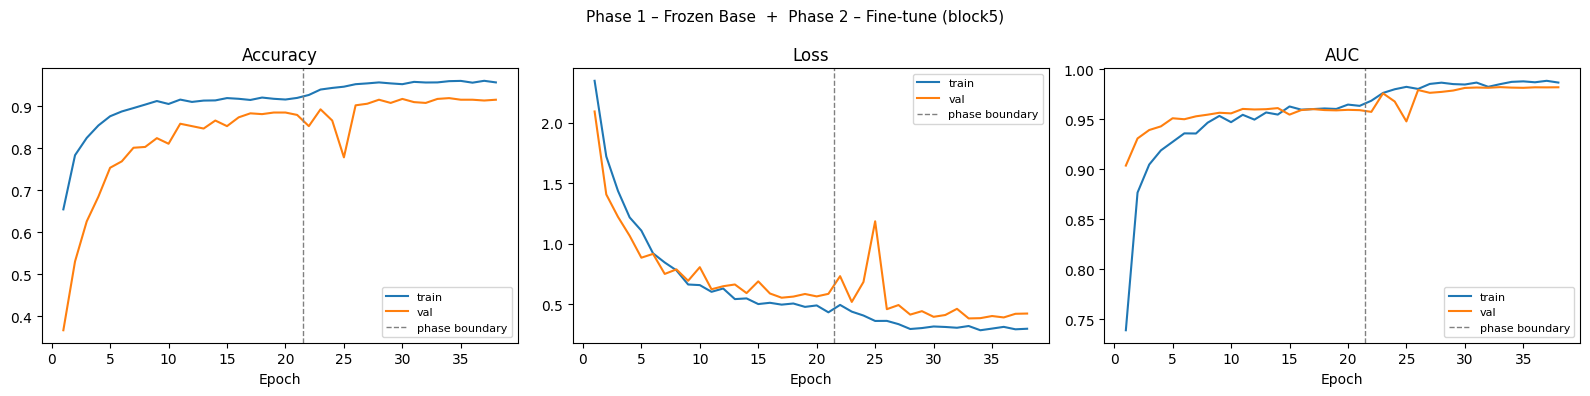

VGG16 Frozen   — best val F1=0.945  @ threshold=0.05
VGG16 Finetuned — best val F1=0.970  @ threshold=0.05


In [33]:
# ── 6a+6b: Combined training curves + threshold tuning ──────────────────────

visualization.plot_combined_training_curves(
    teacher_history,
    finetune_history,
    phase1_label="Phase 1 – Frozen Base",
    phase2_label="Phase 2 – Fine-tune (block5)",
)

# Load best checkpoints for evaluation
frozen_best   = training_utils.load_model_compat(TEACHER_CHECKPOINT_PATH)
finetune_best = training_utils.load_model_compat(FINETUNE_CHECKPOINT_PATH)
#finetune_best = load_model_compat_local(FINETUNE_CHECKPOINT_PATH)
#finetune_best   = finetune_history.model

# Tune decision threshold on validation set (maximises PNEUMONIA F1)
frozen_threshold,   frozen_val_f1,   _, _ = training_utils.tune_threshold(frozen_best,   val_ds)
finetune_threshold, finetune_val_f1, _, _ = training_utils.tune_threshold(finetune_best, val_ds)

print(f"VGG16 Frozen   — best val F1={frozen_val_f1:.3f}  @ threshold={frozen_threshold:.2f}")
print(f"VGG16 Finetuned — best val F1={finetune_val_f1:.3f}  @ threshold={finetune_threshold:.2f}")


In [25]:
# ── 6c: Test set metrics for both VGG16 models ──────────────────────────────

frozen_metrics,   frozen_report,   y_true, frozen_prob,   frozen_pred   = training_utils.evaluate_model(frozen_best,   test_ds, frozen_threshold)
finetune_metrics, finetune_report, y_true, finetune_prob, finetune_pred = training_utils.evaluate_model(finetune_best, test_ds, finetune_threshold)

print("── VGG16 Frozen (Phase 1 best) ──────────────────────────────")
print(f"  Accuracy:    {frozen_metrics['accuracy']:.4f}")
print(f"  AUC:         {frozen_metrics['auc']:.4f}")
print(f"  Precision:   {frozen_metrics['precision']:.4f}")
print(f"  Recall:      {frozen_metrics['recall']:.4f}")
print(f"  F1:          {frozen_metrics['f1']:.4f}")
print(f"  Threshold:   {frozen_threshold:.2f}")

print("\n── VGG16 Fine-tuned (Phase 2 best) ─────────────────────────")
print(f"  Accuracy:    {finetune_metrics['accuracy']:.4f}")
print(f"  AUC:         {finetune_metrics['auc']:.4f}")
print(f"  Precision:   {finetune_metrics['precision']:.4f}")
print(f"  Recall:      {finetune_metrics['recall']:.4f}")
print(f"  F1:          {finetune_metrics['f1']:.4f}")
print(f"  Threshold:   {finetune_threshold:.2f}")

# Save both models with metadata
save_model_with_meta(frozen_best,   "vgg16_frozen",    frozen_metrics,   teacher_history,  {"lr": 1e-4, "freeze_base": True},                    frozen_threshold)
save_model_with_meta(finetune_best, "vgg16_finetuned", finetune_metrics, finetune_history, {"lr": 1e-5, "freeze_base": False, "unfrozen": "block5"}, finetune_threshold)


── VGG16 Frozen (Phase 1 best) ──────────────────────────────
  Accuracy:    0.8478
  AUC:         0.9281
  Precision:   0.8158
  Recall:      0.9769
  F1:          0.8891
  Threshold:   0.05

── VGG16 Fine-tuned (Phase 2 best) ─────────────────────────
  Accuracy:    0.8622
  AUC:         0.9628
  Precision:   0.8262
  Recall:      0.9872
  F1:          0.8995
  Threshold:   0.05
Saved model to: /content/drive/MyDrive/saved_models/vgg16_frozen.keras
Saved metadata to: /content/drive/MyDrive/saved_models/vgg16_frozen_meta.json
Saved model to: /content/drive/MyDrive/saved_models/vgg16_finetuned.keras
Saved metadata to: /content/drive/MyDrive/saved_models/vgg16_finetuned_meta.json


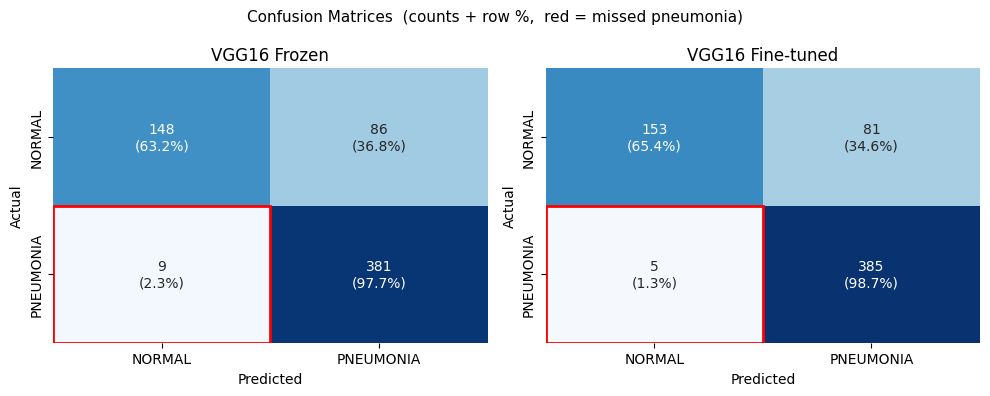

In [26]:
# ── 6d: Side-by-side confusion matrices ─────────────────────────────────────

visualization.plot_confusion_matrices_grid([
    ("VGG16 Frozen",    y_true, frozen_pred),
    ("VGG16 Fine-tuned", y_true, finetune_pred),
])


In [ ]:
# ── 6e: Overlay ROC curves ───────────────────────────────────────────────────

visualization.plot_roc_curves([
    ("VGG16 Frozen",    y_true, frozen_prob,   frozen_threshold),
    ("VGG16 Fine-tuned", y_true, finetune_prob, finetune_threshold),
])


In [ ]:
# ── 6g: Qualitative predictions – best model ────────────────────────────────
# Show 9 test samples from the fine-tuned model with true label, prediction,
# and confidence score.

visualization.plot_sample_predictions(finetune_best, test_ds, finetune_threshold, n=9)


## Final Model Comparison

=== Model Comparison vs. Paper Targets ===
                            Test Acc  Test AUC  Precision  Recall      F1  Threshold  Trainable Params
Model                                                                                                 
Baseline CNN                  0.8285    0.8930     0.8393  0.8974  0.8674       0.33           1207201
Baseline CNN (tuned HP)       0.9231    0.9420     0.9091  0.9744  0.9406       0.62           9476673
VGG16 Frozen (Phase 1)        0.8478    0.9281     0.8158  0.9769  0.8891       0.05            165121
VGG16 Fine-tuned (Phase 2)    0.8622    0.9628     0.8262  0.9872  0.8995       0.05           7244545


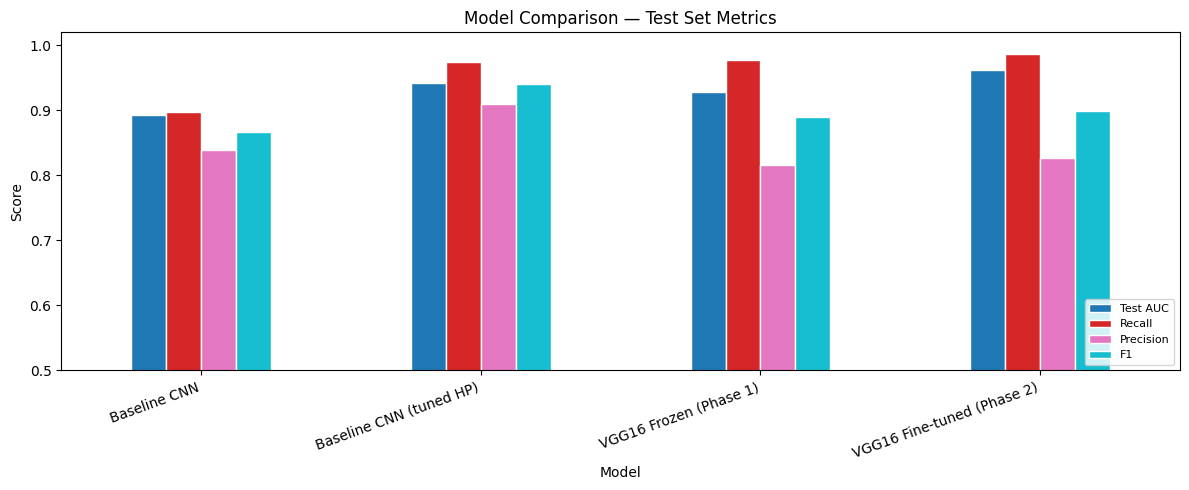

In [35]:
# ── 6f: Final comparison table vs. paper targets ────────────────────────────

import pandas as pd
import matplotlib.pyplot as plt

records = []
for model_name, label in [
    ("baseline_cnn",       "Baseline CNN"),
    ("baseline_cnn_tuned", "Baseline CNN (tuned HP)"),
    ("vgg16_frozen",       "VGG16 Frozen (Phase 1)"),
    ("vgg16_finetuned",    "VGG16 Fine-tuned (Phase 2)"),
]:
    meta = training_utils.load_model_meta(SAVE_DIR, model_name)
    if meta is None:
        continue
    m = meta["metrics"]
    records.append({
        "Model":      label,
        "Test Acc":   round(m.get("accuracy", 0), 4),
        "Test AUC":   round(m.get("auc", 0), 4),
        "Precision":  round(m.get("precision", 0), 4),
        "Recall":     round(m.get("recall", 0), 4),
        "F1":         round(m.get("f1", 0), 4),
        "Threshold":  round(meta.get("threshold", 0), 2),
        "Trainable Params": meta.get("model_params", {}).get("trainable", "—"),
    })

comparison_df = pd.DataFrame(records).set_index("Model")

# ── Styled table ─────────────────────────────────────────────────────────────
metric_cols = ["Test Acc", "Test AUC", "Precision", "Recall", "F1"]
numeric_df  = comparison_df[metric_cols].apply(pd.to_numeric, errors="coerce")

def _highlight(col):
    best_val = col.dropna().max()
    colors = []
    for val in col:
        if pd.isna(val):
            colors.append("")
        elif val == best_val:
            colors.append("background-color: #c6efce; font-weight: bold")
        else:
            colors.append("")
    return colors

def _mark_vs_paper(df):
    """Add check/cross suffix to metric cells based on paper target values."""
    paper_targets = {
        "Test Acc":  0.910,
        "Precision": 0.899,
        "Recall":    0.964,
        "F1":        0.931,
    }
    display = df.copy().astype(str)
    for col, target in paper_targets.items():
        if col not in display.columns:
            continue
        for idx in display.index:
            try:
                val = float(df.loc[idx, col])
                if "Paper" in str(idx):
                    continue
                symbol = " ✓" if val >= target else " ✗"
                display.loc[idx, col] = f"{val:.4f}{symbol}"
            except (ValueError, TypeError):
                pass
    return display

display_df = _mark_vs_paper(numeric_df)
print("=== Model Comparison vs. Paper Targets ===")
print(comparison_df[metric_cols + ["Threshold", "Trainable Params"]].to_string())

# ── Bar chart: AUC / Recall / Precision / F1 ─────────────────────────────────

ax = plot_df[["Test AUC", "Recall", "Precision", "F1"]].plot(
    kind="bar", figsize=(12, 5), colormap="tab10", edgecolor="white"
)
# Draw horizontal reference lines for paper targets
colors_map = {"Recall": "tab:orange", "Precision": "tab:green", "F1": "tab:red"}

ax.set_ylim(0.5, 1.02)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Test Set Metrics")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()
